In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, accuracy_score

#### **relevant functions**

In [2]:
# def analyze_honey(file_path, label):
#     print(f"\n{'='*60}\nAnalyzing {label}\n{'='*60}")
    
#     # Load data (your existing code)
#     df = pd.read_csv(file_path)
#     print(f"Loaded {df.shape[0]} samples, {df.shape[1]} columns")
    
#     # ... all your preprocessing, PCA, PLS-DA, bootstrap ...
#     # (copy everything from your current script, but replace the final print statements with returns)
    
#     # Return results
#     return {
#         'frequency': label,
#         'pca_pc1': var_exp[0]*100,
#         'pca_pc2': var_exp[1]*100,
#         'kfold_acc_mean': mean_acc*100,
#         'kfold_acc_std': std_acc*100,
#         'boot_acc_mean': mean_boot*100,
#         'boot_acc_std': std_boot*100
#     }

### **Load data**

In [3]:
file_path = "NMR Binning Data commercial honey 400MHz.xlsx - Sheet1.csv"   # <-- UPDATE THIS

# Column names
sample_col = "Samplecode"
class_col = "Type"            # second column name (Stingless bee / Honey bee)

In [4]:
df = pd.read_csv(file_path)
print(f"Loaded {df.shape[0]} samples, {df.shape[1]} columns")

Loaded 20 samples, 239 columns


In [5]:
df.head()

,Samplecode,Species,Type,9.98,9.94,9.9,9.86,9.82,9.78,9.74,...,0.91,0.87,0.83,0.79,0.75,0.71,0.67,0.63,0.59,0.55
0,H1,L. coniforn,Stingless bee,-0.008130,0.004153,-0.010163,0.036254,-0.057596,0.041652,-0.005691,...,2.631892,0.055972,1.288434,-0.031817,0.018871,0.000107,0.012105,0.015958,-0.009111,0.004236
1,H2,T. apicalis,Stingless bee,-0.000904,-0.001884,0.035719,-0.009815,-0.032039,0.030696,-0.016021,...,12.889050,0.932005,-0.128574,0.562806,0.002882,0.002124,-0.002163,0.009729,-0.005195,0.021724
2,H3,H. itama,Stingless bee,0.013770,0.004746,-0.019005,0.019840,-0.012979,-0.003128,0.002826,...,1.920728,-0.068650,0.263713,-0.049377,0.056343,0.030449,-0.021226,0.013937,-0.019206,-0.009160
3,H4,H. itama,Stingless bee,0.018562,-0.011448,-0.029900,0.013662,0.004060,0.000395,0.003148,...,2.924609,-0.059312,0.035719,-0.009196,-0.001213,0.009848,-0.016705,0.003558,0.005959,-0.015176
4,H5,H. itama,Stingless bee,0.002643,0.003396,0.003265,-0.007626,0.032096,-0.025226,-0.002353,...,-0.073081,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
# Separate metadata and bin intensities
sample_ids = df[sample_col]
y = df[class_col]                       # class labels (string)
X = df.drop(columns=[sample_col, "Species", class_col])  # only bin columns

In [7]:
X.head()

,9.98,9.94,9.9,9.86,9.82,9.78,9.74,9.7,9.66,9.62,...,0.91,0.87,0.83,0.79,0.75,0.71,0.67,0.63,0.59,0.55
0,-0.008130,0.004153,-0.010163,0.036254,-0.057596,0.041652,-0.005691,0.011552,-0.019038,0.003600,...,2.631892,0.055972,1.288434,-0.031817,0.018871,0.000107,0.012105,0.015958,-0.009111,0.004236
1,-0.000904,-0.001884,0.035719,-0.009815,-0.032039,0.030696,-0.016021,-0.018677,-0.003293,0.036892,...,12.889050,0.932005,-0.128574,0.562806,0.002882,0.002124,-0.002163,0.009729,-0.005195,0.021724
2,0.013770,0.004746,-0.019005,0.019840,-0.012979,-0.003128,0.002826,-0.010107,0.013824,0.009016,...,1.920728,-0.068650,0.263713,-0.049377,0.056343,0.030449,-0.021226,0.013937,-0.019206,-0.009160
3,0.018562,-0.011448,-0.029900,0.013662,0.004060,0.000395,0.003148,0.020261,0.008516,-0.010410,...,2.924609,-0.059312,0.035719,-0.009196,-0.001213,0.009848,-0.016705,0.003558,0.005959,-0.015176
4,0.002643,0.003396,0.003265,-0.007626,0.032096,-0.025226,-0.002353,-0.002993,0.006190,-0.023363,...,-0.073081,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
y.unique()

<StringArray>
['Stingless bee', 'Honey bee']
Length: 2, dtype: str

#### **Encoding class labels i.e Type**

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}") 

Classes: ['Honey bee' 'Stingless bee']


In [10]:
y_encoded

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

#### **Scaling(Using Pareto Scaling)**
Pareto is preferred over standard scaler as it identifies more peaks than mean centring alone,
while still being interpretable.

ref:
 https://strathprints.strath.ac.uk/70001/1/Alghamdi_etal_AAS2019_Investigation_of_metabolomics_techniques_by_analysis_of_MS_propolis.pdf#2#1


In [11]:
X_np = X.values   # convert to numpy array

# Step 1: Mean-center using StandardScaler (no scaling of variance)
scaler = StandardScaler(with_mean=True, with_std=False)
X_centered = scaler.fit_transform(X_np)   # shape (20, 236)

# Step 2: Get standard deviation of original data
std = X_np.std(axis=0)   # shape (236,)

# Step 3: Pareto scaling (divide by sqrt of std)
X_pareto = X_centered / np.sqrt(std)

#### **PCA**

In [12]:
pca = PCA(n_components=5)
scores = pca.fit_transform(X_pareto)
var_exp = pca.explained_variance_ratio_
print(f"PCA: PC1 = {var_exp[0]*100:.1f}%, PC2 = {var_exp[1]*100:.1f}%")


PCA: PC1 = 64.0%, PC2 = 12.5%


**Summary:**

- PC1 explains 64.0% of the total variance in binned NMR data 
- A high PC1 value (≥60%) is common in NMR honey data because the major sugar signals dominate the spectral fingerprint 
- PC2 explains 12.5% – the second most important direction, orthogonal to PC1.
Cumulative variance (PC1+PC2) = 76.5% => it captures 3/4 of the information in the original bins


Therefore, 
Principal component analysis (PCA) of the Pareto‑scaled binned data revealed that the first two principal components (PC1 and PC2) accounted for 76.5% of the total variance (PC1: 64.0%, PC2: 12.5%).

**PCA Scores Plot**

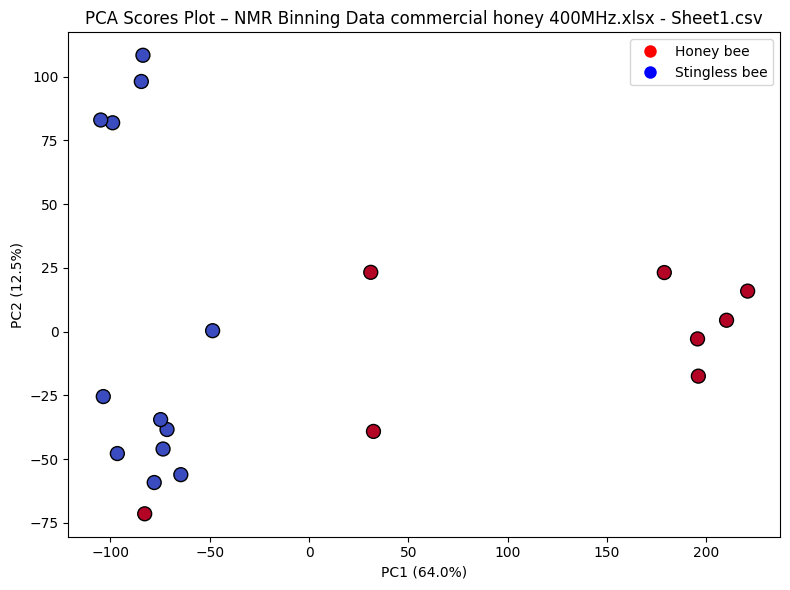

In [13]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(scores[:,0], scores[:,1], c=y_encoded, cmap='coolwarm', edgecolor='k', s=100)
plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
plt.title(f'PCA Scores Plot – {file_path.split("/")[-1]}')
# Create legend
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red', markersize=10, label=le.classes_[0]),
           plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=le.classes_[1])]
plt.legend(handles=handles)
plt.tight_layout()
plt.savefig('pca_scores.png', dpi=300)
plt.show()


#### **PLS-DA with boostrap cross-validation**

- since our data is small sample and high dimensions boostrap or k-fold would be preffered to Leave one out amongst cross validation techniques

In [14]:
pls = PLSRegression(n_components=2)
n_folds = 5          # number of folds
n_repeats = 10       # number of repeats

In [15]:
#  repeated k-fold
rkf = RepeatedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=42)

# Store accuracies and predictions
accuracies = []
all_y_true = []
all_y_pred = []

# For each split (fold and repeat)
for train_idx, test_idx in rkf.split(X_pareto):
    X_train, X_test = X_pareto[train_idx], X_pareto[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    pls = PLSRegression(n_components=2)
    pls.fit(X_train, y_train)
    y_pred_cont = pls.predict(X_test)
    y_pred_class = (y_pred_cont > 0.5).astype(int).flatten()
    
    acc = accuracy_score(y_test, y_pred_class)
    accuracies.append(acc)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred_class)

mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\nRepeated {n_folds}-fold CV ({n_repeats} repeats):")
print(f"Mean accuracy = {mean_acc*100:.1f}% ± {std_acc*100:.1f}%")



Repeated 5-fold CV (10 repeats):
Mean accuracy = 82.0% ± 21.2%


#### **Overall confusion matrix (aggregated across all folds)**

Confusion matrix (aggregated):
[[112   8]
 [ 28  52]]


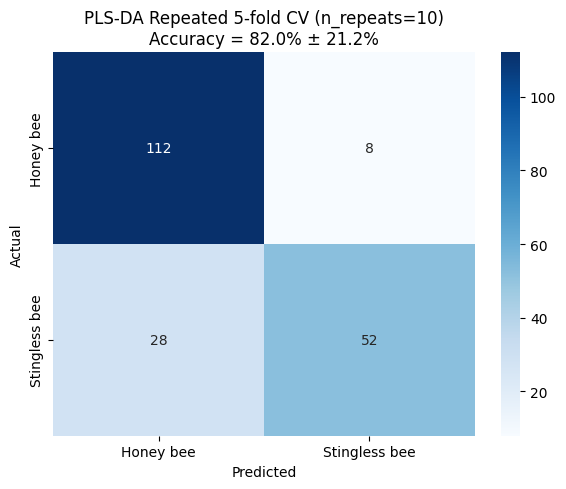

In [16]:

cm = confusion_matrix(all_y_true, all_y_pred)
print("Confusion matrix (aggregated):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'PLS-DA Repeated {n_folds}-fold CV (n_repeats={n_repeats})\nAccuracy = {mean_acc*100:.1f}% ± {std_acc*100:.1f}%')
plt.tight_layout()
plt.savefig('plsda_confusion_kfold.png', dpi=300)
plt.show()

####  **BOOTSTRAP VALIDATION**

In [17]:
def bootstrap_plsda(X, y, n_bootstrap=1000, test_size=0.2):
    accuracies = []
    n_samples = len(y)
    n_test = int(n_samples * test_size)
    for _ in range(n_bootstrap):
        # Bootstrap sample for training (with replacement)
        train_idx = resample(range(n_samples), replace=True, n_samples=n_samples - n_test, random_state=None)
        test_idx = list(set(range(n_samples)) - set(train_idx))
        if len(test_idx) == 0:
            continue
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        pls = PLSRegression(n_components=2)
        pls.fit(X_train, y_train)
        y_pred_cont = pls.predict(X_test)
        y_pred_class = (y_pred_cont > 0.5).astype(int).flatten()
        acc = accuracy_score(y_test, y_pred_class)
        accuracies.append(acc)
    return np.mean(accuracies), np.std(accuracies)

mean_boot, std_boot = bootstrap_plsda(X_pareto, y_encoded, n_bootstrap=1000)
print(f"\nBootstrap validation (1000 iterations, test size ≈20%):")
print(f"Mean accuracy = {mean_boot*100:.1f}% ± {std_boot*100:.1f}%")

/home/josephridge/Desktop/NMR data/env/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:308: UserWarning: y residual is constant at iteration 0
  warnings.warn(f"y residual is constant at iteration {k}")



Bootstrap validation (1000 iterations, test size ≈20%):
Mean accuracy = 77.2% ± 13.9%


**Summary**
- Both accuracies are well above chance (50%) – your PLS‑DA model is genuinely able to distinguish Stingless bee from Honey bee based on the binned NMR data
- The high standard deviation (especially 21.2% for k‑fold) reflects the small sample size (n=20) and high dimensionality (236 bins). With only 20 samples, different splits produce widely varying test accuracies (this expected)
- Bootstrap gives a slightly lower mean (77.9%) and a much tighter standard deviation (±13.7%) :-bootstrap is known to be more stable and less optimistic. The lower standard deviation suggests it is a more reliable estimate of true model performance.